<a href="https://colab.research.google.com/github/gopinathmuthukumaran/Cardeko-Car-Price-Prediction-Model-Project/blob/main/Cardeko_Car_Price_Prediction_Model_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')


In [5]:
df=pd.read_csv(r"/content/cardekho_dataset (1).csv")
df.head(10)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
5,5,Maruti Wagon R,Maruti,Wagon R,8,35000,Individual,Petrol,Manual,18.90,998,67.10,5,350000
6,6,Hyundai i10,Hyundai,i10,8,40000,Dealer,Petrol,Manual,20.36,1197,78.90,5,315000
7,7,Maruti Wagon R,Maruti,Wagon R,3,17512,Dealer,Petrol,Manual,20.51,998,67.04,5,410000
8,8,Hyundai Venue,Hyundai,Venue,2,20000,Individual,Petrol,Automatic,18.15,998,118.35,5,1050000
9,12,Maruti Swift,Maruti,Swift,4,28321,Dealer,Petrol,Manual,16.60,1197,85.00,5,511000


In [6]:
# Data Preprocessing

In [7]:
print("The size of dataframe is : ", df.shape)
print("_"*100)
print("The column Name, Record Count and Data Types are as follows : ")
df.info()
print("_"*100)

The size of dataframe is :  (15411, 14)
____________________________________________________________________________________________________
The column Name, Record Count and Data Types are as follows : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats     

In [8]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 8 numerical features : ['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

We have 6 categorical features : ['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


In [9]:
print("Missing Value presence in different columns of DataFrame are as follows : ")
print("_"* 100)

total = df.isnull().sum().sort_values(ascending = False)
percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False)
pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])

Missing Value presence in different columns of DataFrame are as follows : 
____________________________________________________________________________________________________


,Total,Percent
Unnamed: 0,0,0.0
car_name,0,0.0
brand,0,0.0
model,0,0.0
vehicle_age,0,0.0
km_driven,0,0.0
seller_type,0,0.0
fuel_type,0,0.0
transmission_type,0,0.0
mileage,0,0.0


In [10]:
print("Summary Statistics of numerical features for DataFrame are as follows : ")
print("_"*100)
df.describe()

Summary Statistics of numerical features for DataFrame are as follows : 
____________________________________________________________________________________________________


,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [11]:
print("Summary Statistics of categorical features for DataFrame are as follows : ")
print("_"*100)
df.describe(include = "object")

Summary Statistics of categorical features for DataFrame are as follows : 
____________________________________________________________________________________________________


,car_name,brand,model,seller_type,fuel_type,transmission_type
count,15411,15411,15411,15411,15411,15411
unique,121,32,120,3,5,2
top,Hyundai i20,Maruti,i20,Dealer,Petrol,Manual
freq,906,4992,906,9539,7643,12225


In [12]:
print("_"*100)
print("The percentage of each category in categorical column are as follows : ")
print("_"* 100 + '\n')
for col in categorical_features:
  print(df[col].value_counts(normalize = True) * 100)
  print("_"* 100)

____________________________________________________________________________________________________
The percentage of each category in categorical column are as follows : 
____________________________________________________________________________________________________

car_name
Hyundai i20              5.878918
Maruti Swift Dzire       5.775096
Maruti Swift             5.067809
Maruti Alto              5.048342
Honda City               4.912076
                           ...   
Mercedes-AMG C           0.006489
Rolls-Royce Ghost        0.006489
Maserati Quattroporte    0.006489
Isuzu MUX                0.006489
Force Gurkha             0.006489
Name: proportion, Length: 121, dtype: float64
____________________________________________________________________________________________________
brand
Maruti           32.392447
Hyundai          19.349815
Honda             9.635974
Mahindra          6.560249
Toyota            5.145675
Ford              5.126209
Volkswagen        4.023100


In [13]:
# Data Analysis

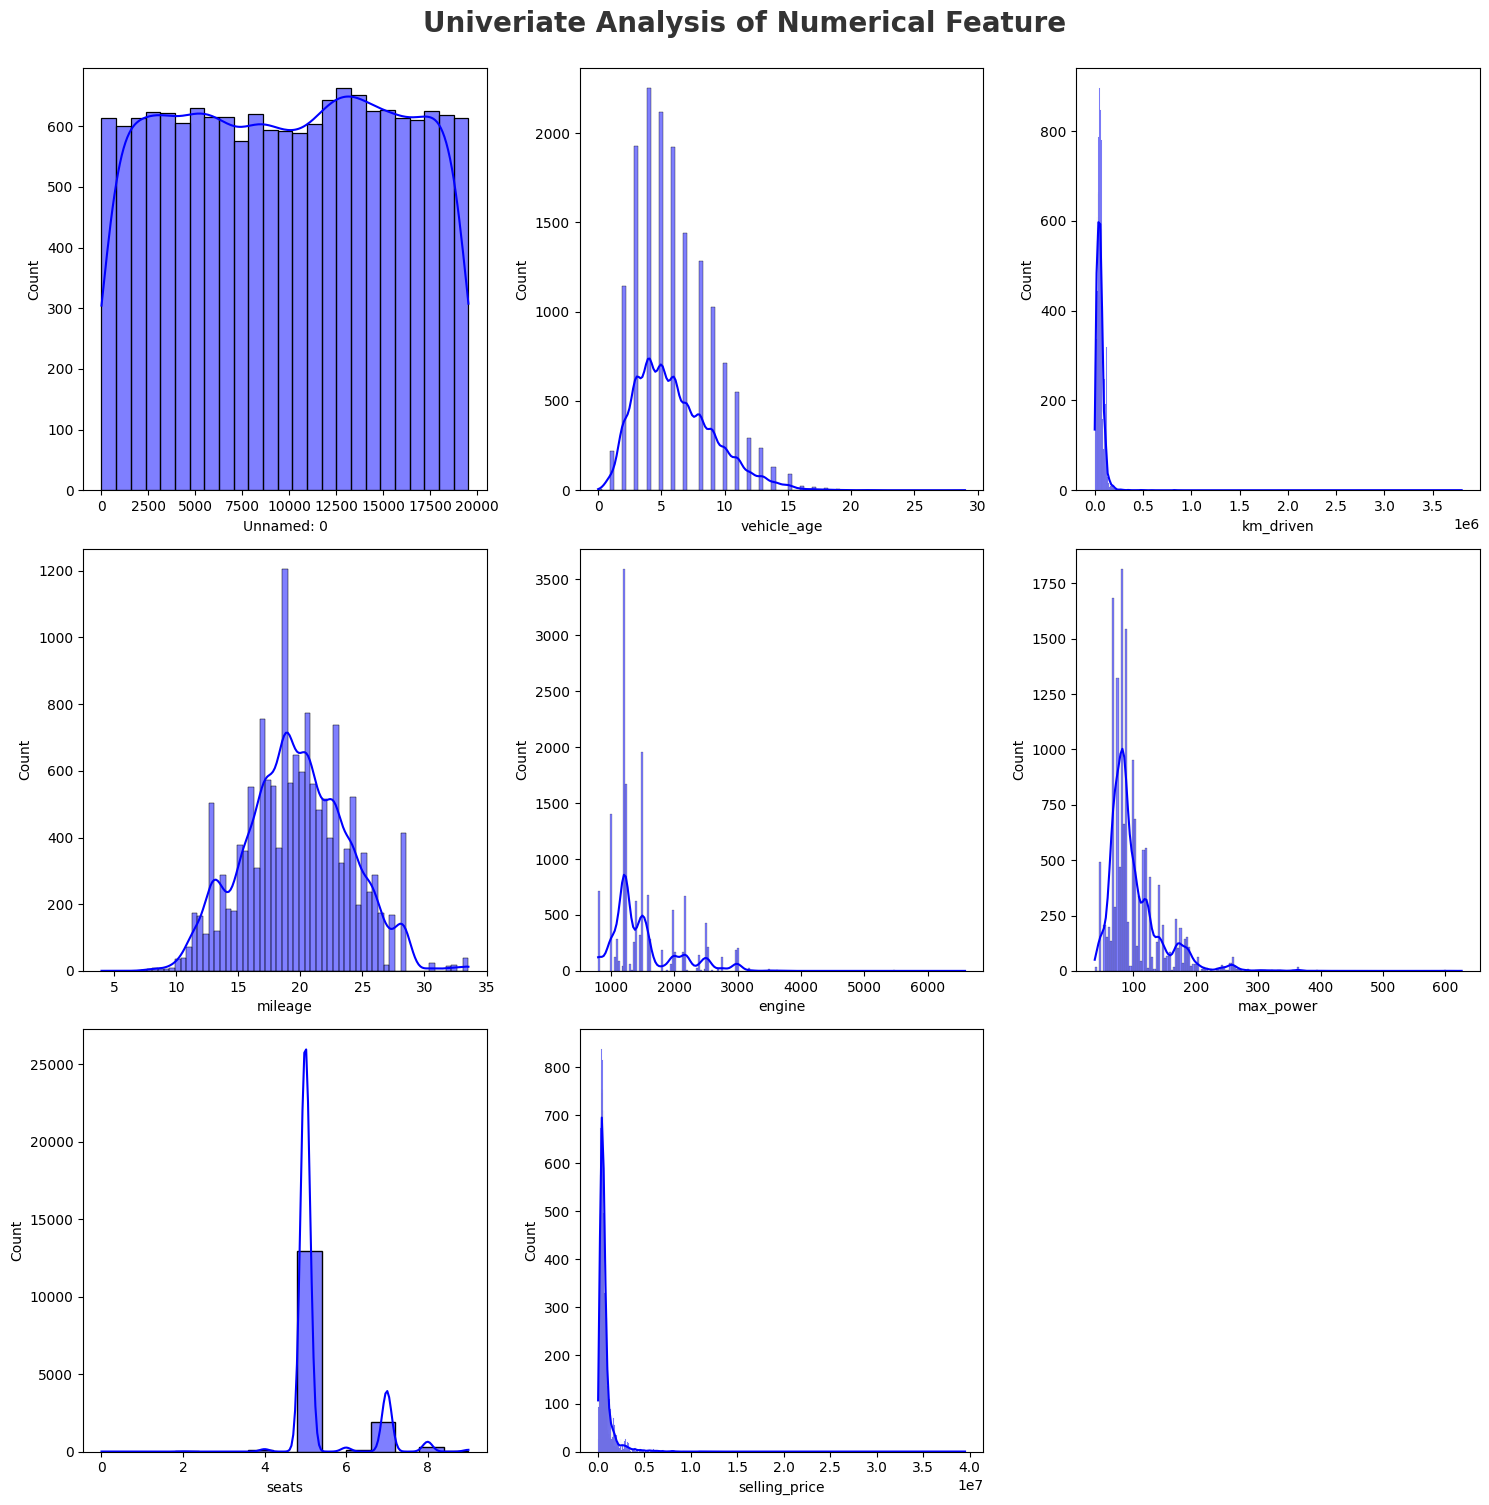

In [14]:
# Univeriate Analysis of Numerical Feature

plt.figure(figsize = (15,15))
plt.suptitle("Univeriate Analysis of Numerical Feature", fontsize = 20, fontweight = 'bold', alpha = 0.8, y=1.0)

for i in range (0, len(numeric_features)):
  plt.subplot(3,3,i+1)
  sns.histplot(x = df[numeric_features[i]],kde=True, color = 'b')
  plt.xlabel(numeric_features[i])

plt.tight_layout()
plt.show()

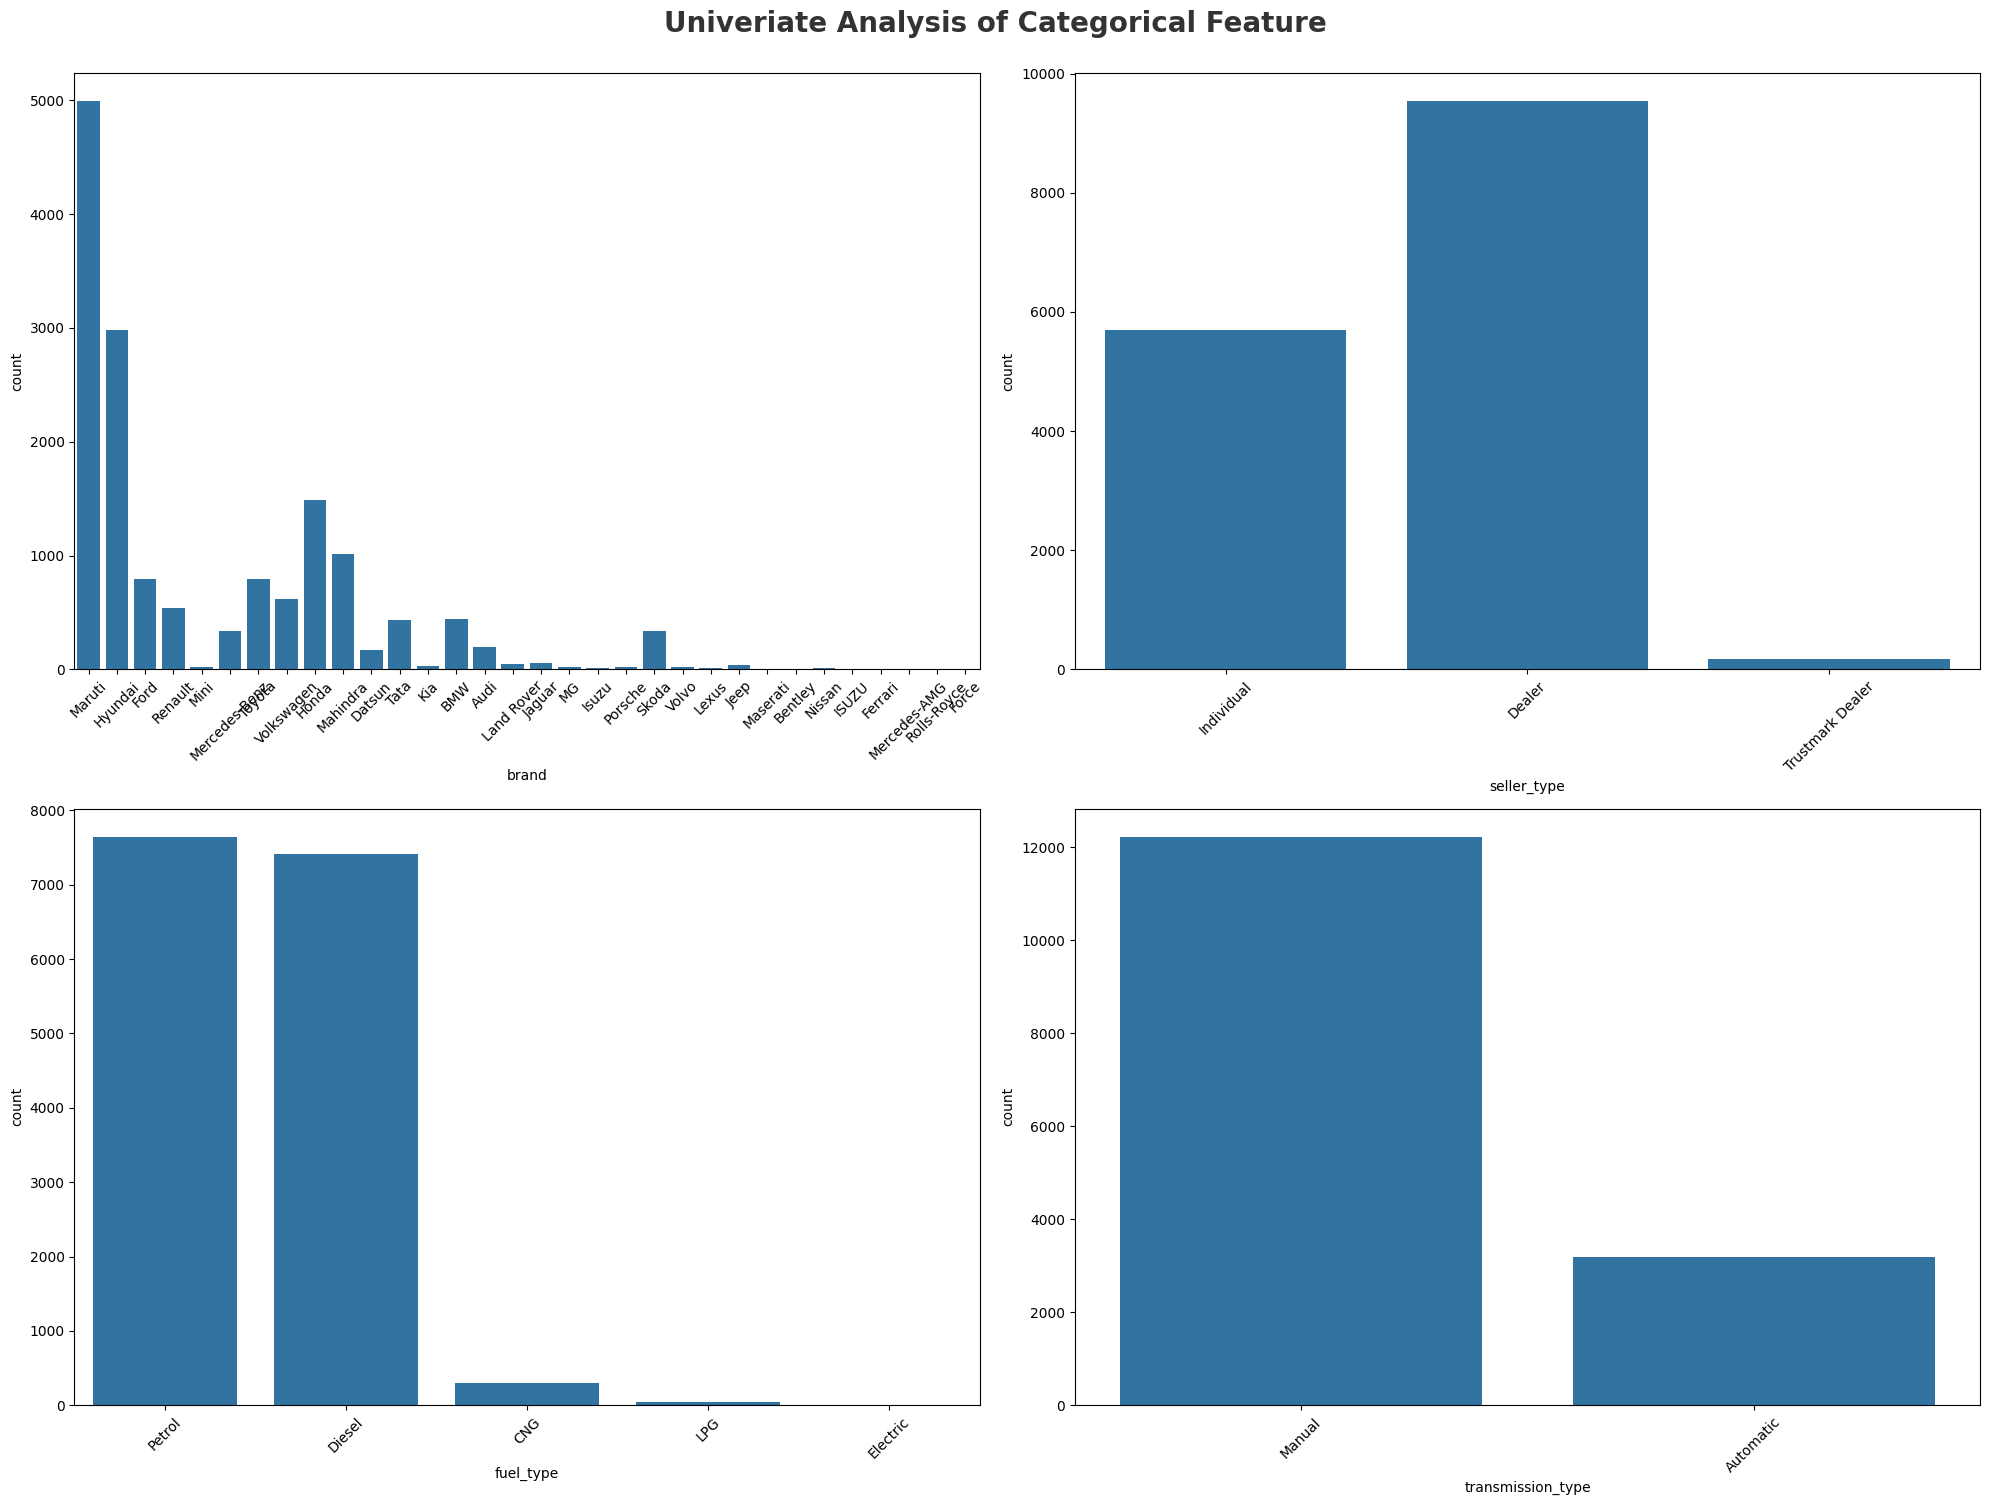

In [15]:
#Univeriate Analysis of Categorical Feature

plt.figure(figsize=(20,15))
plt.suptitle("Univeriate Analysis of Categorical Feature", fontsize = 20, fontweight = 'bold', alpha = 0.8, y=1.0)

cat1 = ['brand', 'seller_type', 'fuel_type', 'transmission_type']

for i in range (0, len(cat1)):
  plt.subplot(2,2,i+1)
  sns.countplot(x = df[cat1[i]])
  plt.xlabel(cat1[i])
  plt.xticks(rotation=45)

plt.tight_layout()


In [16]:
# Bivariate analysis

continuous_features = [feature for feature in numeric_features if len(df[feature].unique()) >= 10]
print("Num of continuous features :", continuous_features)

Num of continuous features : ['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'selling_price']


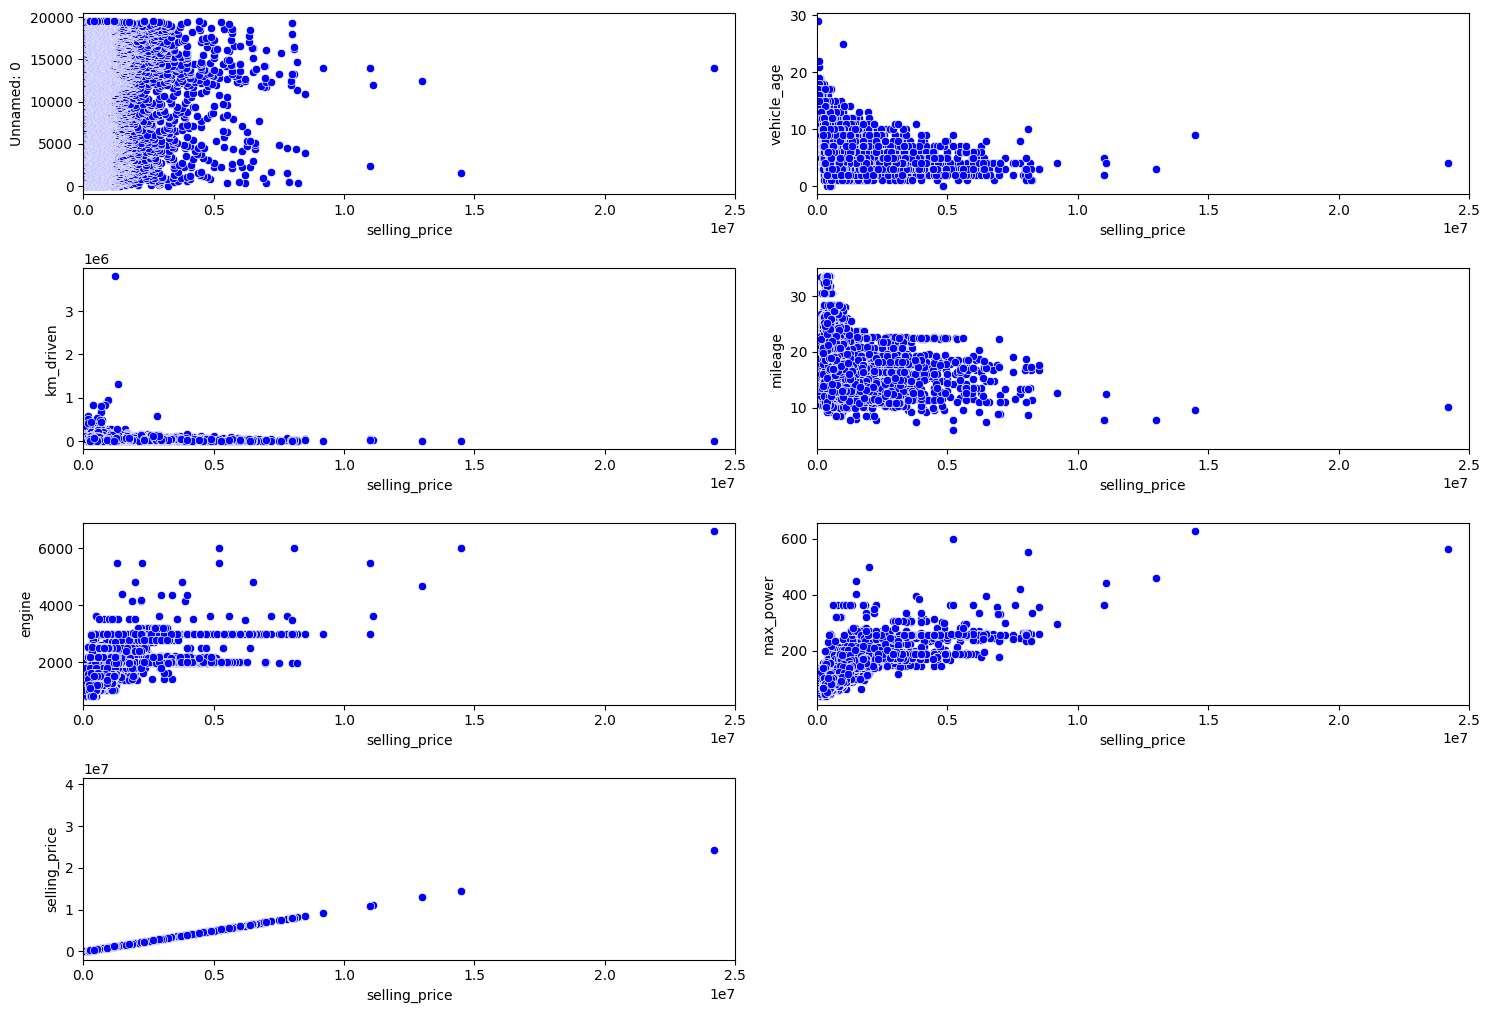

In [17]:

plt.figure(figsize=(15, 20))

for i in range(len(continuous_features)):
    ax = plt.subplot(8, 2, i + 1)
    sns.scatterplot(
        data=df,
        x="selling_price",
        y=continuous_features[i],
        color="b",
    )
    plt.xlim(0, 25000000)
    plt.tight_layout()


In [18]:
# Multivariate Anaylsis

In [19]:
df[numeric_features].corr()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
Unnamed: 0,1.000000,-0.006250,-0.003778,-0.014699,0.012972,0.039367,-0.031832,0.030523
vehicle_age,-0.006250,1.000000,0.333891,-0.257394,0.098965,0.005208,0.030791,-0.241851
km_driven,-0.003778,0.333891,1.000000,-0.105239,0.192885,0.044421,0.192830,-0.080030
mileage,-0.014699,-0.257394,-0.105239,1.000000,-0.632987,-0.533128,-0.440280,-0.305549
engine,0.012972,0.098965,0.192885,-0.632987,1.000000,0.807368,0.551236,0.585844
max_power,0.039367,0.005208,0.044421,-0.533128,0.807368,1.000000,0.172257,0.750236
seats,-0.031832,0.030791,0.192830,-0.440280,0.551236,0.172257,1.000000,0.115033
selling_price,0.030523,-0.241851,-0.080030,-0.305549,0.585844,0.750236,0.115033,1.000000


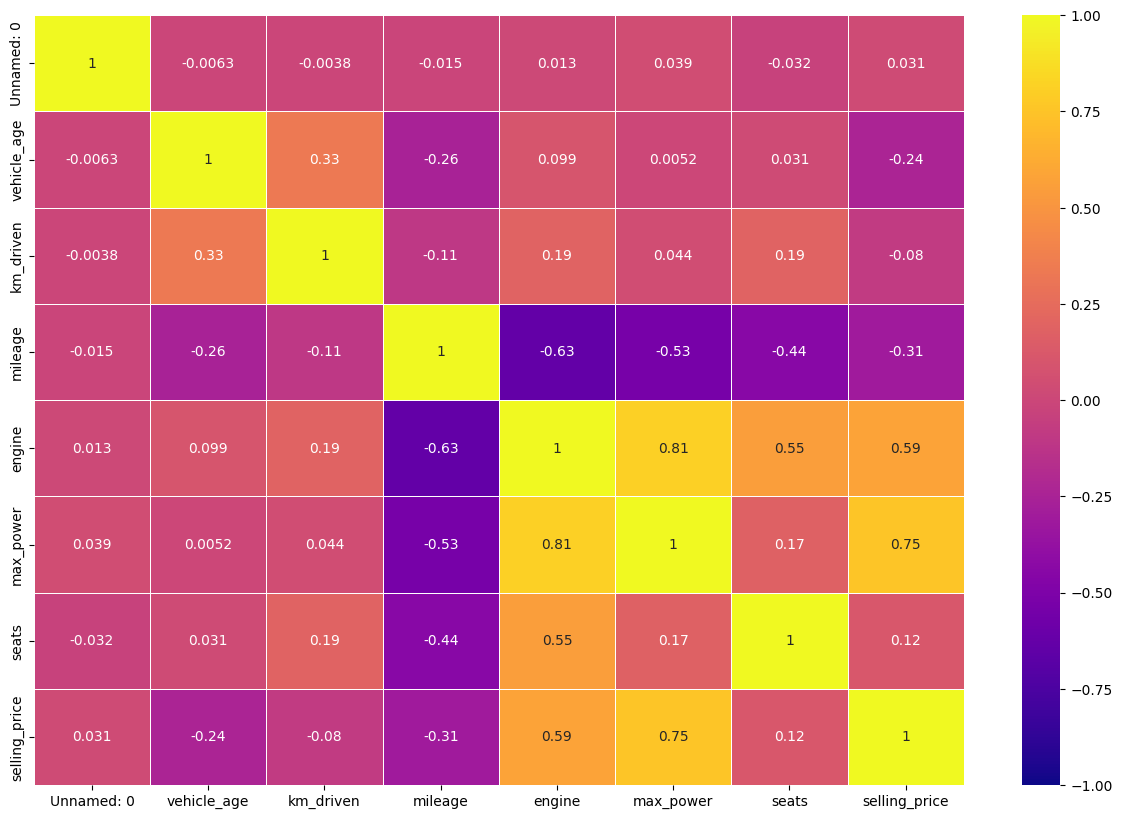

In [20]:
plt.figure(figsize = (15,10))
sns.heatmap(data = df[numeric_features].corr(), annot = True, cmap = 'plasma', vmin = -1, vmax = 1, linecolor ='White', linewidths=0.5)
plt.show()

In [21]:
from scipy.stats import chi2_contingency

chi2_test = []

for feature in categorical_features:
    if chi2_contingency(pd.crosstab(df['selling_price'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject Null Hypothesis')
    else:
        chi2_test.append('Fail to Reject Null Hypothesis')

test_result = pd.DataFrame(data={'Categorical Features': categorical_features, 'Hypothesis Result': chi2_test})

print('-' * 100)
print('Chi-Squarred Test (Checking Multi-collinearity for Categorical features) results are as follows :')
print('-' * 100)

test_result

----------------------------------------------------------------------------------------------------
Chi-Squarred Test (Checking Multi-collinearity for Categorical features) results are as follows :
----------------------------------------------------------------------------------------------------


,Categorical Features,Hypothesis Result
0,car_name,Reject Null Hypothesis
1,brand,Reject Null Hypothesis
2,model,Reject Null Hypothesis
3,seller_type,Reject Null Hypothesis
4,fuel_type,Reject Null Hypothesis
5,transmission_type,Reject Null Hypothesis


In [22]:
# Data Cleaning & Feature Engineer

In [23]:
#1) Removing unnecessary Feature
df_model = df.copy() #Creating a copy
df_model.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [24]:
df_model.drop(labels = ['car_name', 'brand', 'model'], axis = 1, inplace = True)
df_model.head()

,Unnamed: 0,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [25]:
df_model = pd.get_dummies(df_model, dtype = float)
df_model

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
0,0,9,120000,19.70,796,46.30,5,120000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1,5,20000,18.90,1197,82.00,5,550000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,2,11,60000,17.00,1197,80.00,5,215000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,3,9,37000,20.92,998,67.10,5,226000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,4,6,30000,22.77,1498,98.59,5,570000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,9,10723,19.81,1086,68.05,5,250000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15407,19540,2,18000,17.50,1373,91.10,7,925000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15408,19541,6,67000,21.14,1498,103.52,5,425000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
15409,19542,5,3800000,16.00,2179,140.00,7,1225000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [26]:
# Creating feature Matrix
x = df_model.drop("selling_price", axis = 1)
x

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
0,0,9,120000,19.70,796,46.30,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1,5,20000,18.90,1197,82.00,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,2,11,60000,17.00,1197,80.00,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,3,9,37000,20.92,998,67.10,5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,4,6,30000,22.77,1498,98.59,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,9,10723,19.81,1086,68.05,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15407,19540,2,18000,17.50,1373,91.10,7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15408,19541,6,67000,21.14,1498,103.52,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
15409,19542,5,3800000,16.00,2179,140.00,7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [27]:
y = df_model["selling_price"]
y

,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000
...,...
15406,250000
15407,925000
15408,425000
15409,1225000


In [28]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor()
print(model.fit(x,y))

ExtraTreesRegressor()


In [29]:
print("-"* 50)
print("Checking for feature importan")
print("-"* 50)
print(model.feature_importances_)

--------------------------------------------------
Checking for feature importan
--------------------------------------------------
[1.49163328e-02 1.70588317e-01 4.14544301e-02 5.20991424e-02
 1.22717785e-01 4.05027224e-01 1.46112894e-02 4.75674019e-03
 4.52437607e-03 2.24292256e-05 4.22287486e-05 8.13565551e-03
 1.42556870e-05 2.43359295e-06 2.10702642e-02 6.95308657e-02
 7.04862304e-02]


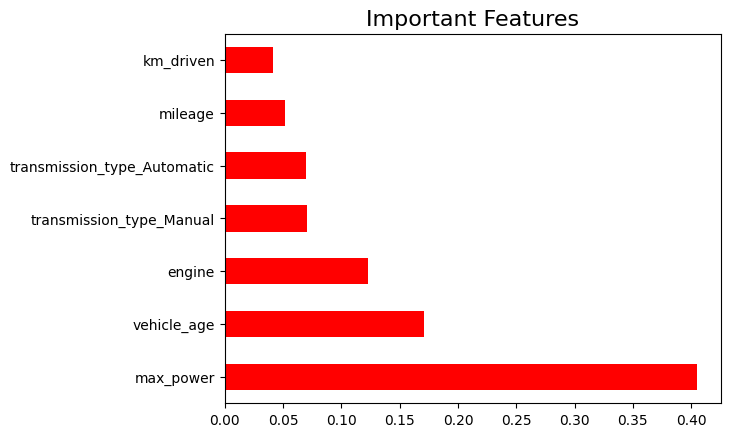

In [30]:
imp_feature = pd.Series(model.feature_importances_, index=x.columns)

imp_feature.nlargest(7).plot(kind='barh', color='red')
plt.title('Important Features', fontsize=16)
plt.show()

In [31]:
# Model Building & Evaluation

In [32]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=3)

In [33]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, explained_variance_score, r2_score

In [47]:
models = [LinearRegression, SVR, DecisionTreeRegressor, RandomForestRegressor, Ridge, Lasso]
mse = []
rmse = []
evs = []
r_square_score = []

for model in models:
  regressor = model().fit(x_train, y_train)
  pred = regressor.predict(x_test)
  mse.append(mean_squared_error(y_true=y_test, y_pred=pred))
  rmse.append(np.sqrt(mean_squared_error(y_true=y_test, y_pred=pred)))
  evs.append(explained_variance_score(y_true=y_test, y_pred=pred))
  r_square_score.append(r2_score(y_true=y_test, y_pred=pred))

In [48]:
ML_model_df = pd.DataFrame(
    {
        "Model": [
            "Linear Regression",
            "Support Vector Regression",
            "Decision Tree",
            "Random Forest Regressor",
            "Ridge",
            "Lasso",
        ],
        "Mean Squared Error": mse,
        "Root Mean Squared Error": rmse,
        "Explained Variance": evs,
        "R-Square Score (Accuracy)": r_square_score,})

ML_model_df.set_index("Model", inplace=True)
ML_model_df

,Mean Squared Error,Root Mean Squared Error,Explained Variance,R-Square Score (Accuracy)
Model,,,,
Linear Regression,2.185951e+11,467541.503339,0.685280,0.685091
Support Vector Regression,7.409400e+11,860778.727762,0.000098,-0.067400
Decision Tree,1.285627e+11,358556.352336,0.814793,0.814792
Random Forest Regressor,5.399738e+10,232373.356767,0.922256,0.922211
Ridge,2.185917e+11,467537.912695,0.685285,0.685096
Lasso,2.185942e+11,467540.613827,0.685281,0.685093


In [49]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, explained_variance_score, r2_score
import numpy as np

param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf = RandomForestRegressor()

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid, n_iter=100, cv=3,verbose=2,random_state=42,n_jobs=-1,)

random_search.fit(x_train, y_train)

best_rf = random_search.best_estimator_

y_pred = best_rf.predict(x_test)


mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
evs_rf = explained_variance_score(y_test, y_pred)
r2_rf = r2_score(y_test, y_pred)


mse.append(mse_rf)
rmse.append(rmse_rf)
evs.append(evs_rf)
r_square_score.append(r2_rf)



print(f"Best Hyperparameters for RandomForest: {random_search.best_params_}")
print(f"RandomForest MSE: {mse_rf}")
print(f"RandomForest RMSE: {rmse_rf}")
print(f"RandomForest Explained Variance Score: {evs_rf}")
print(f"RandomForest R^2 Score: {r2_rf}")

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Hyperparameters for RandomForest: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 40, 'bootstrap': False}
RandomForest MSE: 42227269262.4273
RandomForest RMSE: 205492.74746916813
RandomForest Explained Variance Score: 0.9391878558629906
RandomForest R^2 Score: 0.939167275581337


In [53]:
import pickle

saved_models = []

for model_class in models:
  model = model_class()
  regressor = model.fit(x_train, y_train)

  model_filename = f"{model_class.__name__}_model.pkl"
  with open(model_filename, 'wb') as model_file:
    pickle.dump(regressor, model_file)

  saved_models.append(model_filename)

In [56]:
saved_models

['LinearRegression_model.pkl',
 'SVR_model.pkl',
 'DecisionTreeRegressor_model.pkl',
 'RandomForestRegressor_model.pkl',
 'Ridge_model.pkl',
 'Lasso_model.pkl']

In [57]:
best_rf

model_filename = f"best_model.pkl"
with open(model_filename, 'wb') as model_file:
  pickle.dump(best_rf, model_file)

In [58]:
import pickle
model_filename = f"best_model.pkl"
model = pickle.load(open(model_filename, 'rb'))

In [66]:
x_test.iloc[4:7]

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
12165,15428,9,90000,11.57,2179,138.1,7,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5622,7147,5,71205,21.40,1197,83.1,5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1941,2493,10,108800,12.80,2494,102.0,7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [73]:
array = [7147, 5, 71205, 21.40, 1197, 83.1, 5, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0]

In [74]:
model.predict([array])

array([558280.])